## Batch -13 Mini Project: Supervised Machine Learning - (Insurance Premium Prediction) Richa Trivedi 

## Task - 1 : Import and Load the Data
## •	Import required libraries (pandas, numpy, matplotlib, seaborn, sklearn, etc.)

In [22]:
# Import Required Libraries
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
import xgboost
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder 
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
sns.set()
%matplotlib inline

In [23]:
# •	Load the dataset and explore the structure using .head(), .info() and .describe()
import pandas as pd

# Load the Health Insurance dataset
df = pd.read_csv('Health_Insurance.csv')
print(df.head())
print(f"Dataset shape: {df.shape}")

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
Dataset shape: (1338, 7)


In [ ]:
df.info()
display(df.describe(include='all'))


## Task 3: Missing Values & Outlier Treatment

In [24]:
# •	Check for missing values and treat them if any

missing_values = df.isnull().sum()

# Display columns with missing values
print("Missing values per column:")
print(missing_values[missing_values > 0])

if (missing_values == 0).all():
    print("No missing values found in the DataFrame.")

Missing values per column:
Series([], dtype: int64)
No missing values found in the DataFrame.


In [25]:
 # Check for duplicate records
duplicates_count = df.duplicated().sum()

print(f"Number of duplicate records found: {duplicates_count}")

# If duplicates exist, remove them
if duplicates_count > 0:
    initial_rows = df.shape[0]
    df.drop_duplicates(inplace=True)
    final_rows = df.shape[0]
    print(f"Original number of records: {initial_rows}")
    print(f"Number of records after removing duplicates: {final_rows}")
    print(f"Successfully removed {initial_rows - final_rows} duplicate records.")
else:
    print("No duplicate records found.")

Number of duplicate records found: 1
Original number of records: 1338
Number of records after removing duplicates: 1337
Successfully removed 1 duplicate records.


In [26]:
df_summary = pd.DataFrame({"variables": df.columns,
                           "data type":df.dtypes,
                           "Missing_count" : df.isnull().sum(),
                           "Missing_percent" : (df.isnull().sum()/len(df))*100,
                           "Unique" : df.nunique(),
                           "count" : df.count()
                          })

with pd.option_context(
    'display.max_columns', None,
    'display.width', None,
    'display.expand_frame_repr', False
):
    print(f"DataSummary: \n {df_summary.sort_values("Unique").set_index("variables")}\n")


DataSummary: 
           data type  Missing_count  Missing_percent  Unique  count
variables                                                         
sex          object              0              0.0       2   1337
smoker       object              0              0.0       2   1337
region       object              0              0.0       4   1337
children      int64              0              0.0       6   1337
age           int64              0              0.0      47   1337
bmi         float64              0              0.0     548   1337
charges     float64              0              0.0    1337   1337



## Task -2 . Exploratory Data Analysis (EDA)

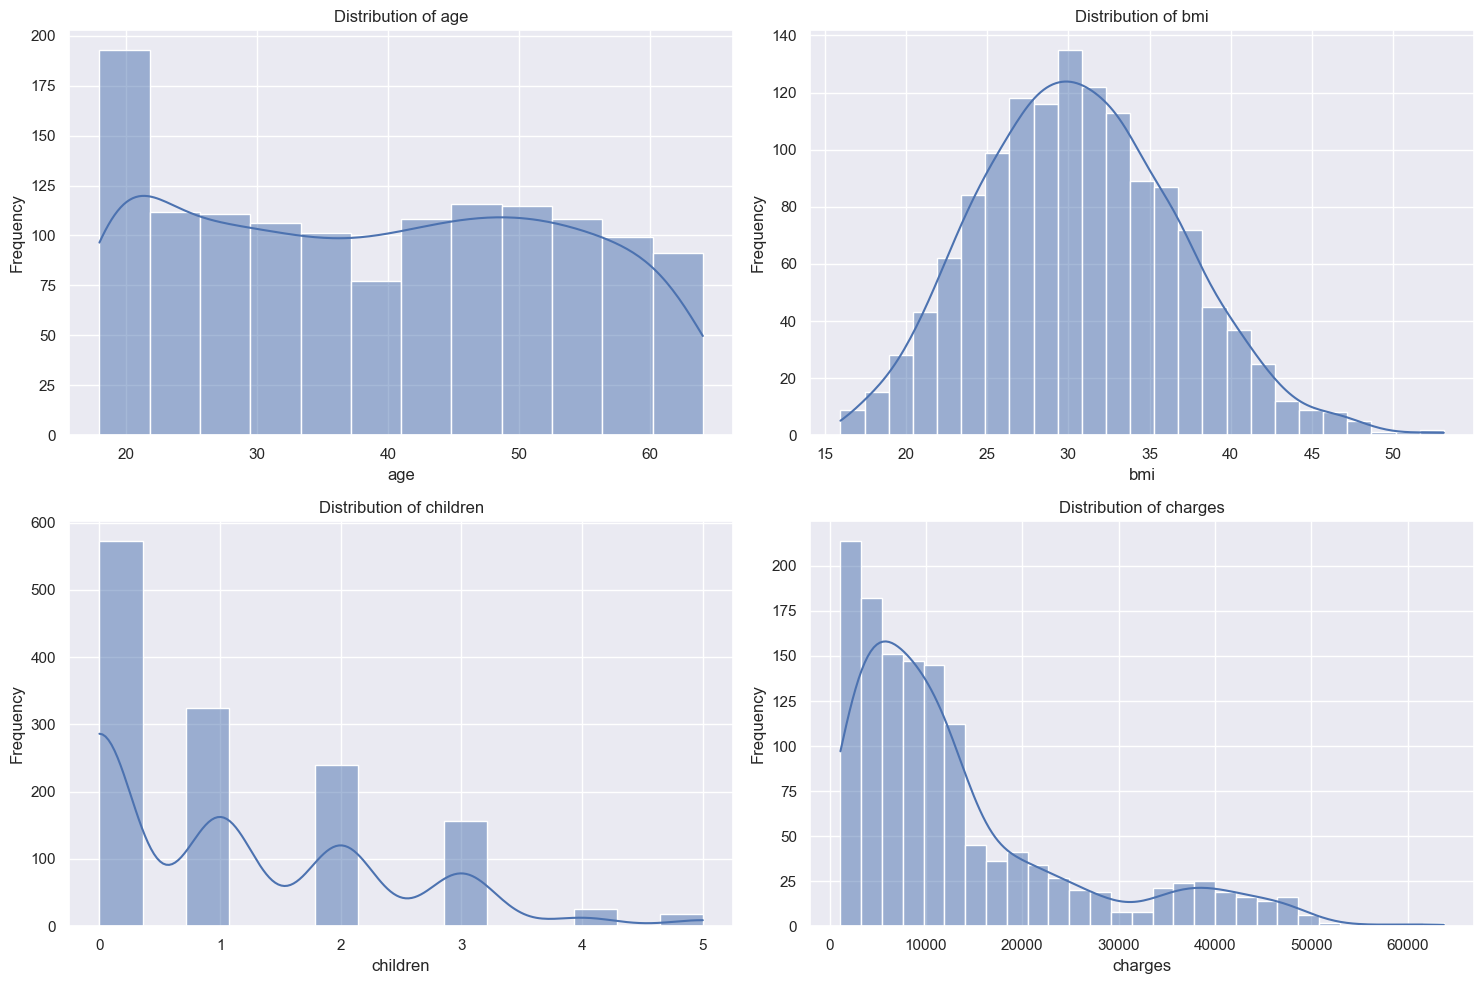

In [27]:
# •	Visualize the distribution of each feature
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size for better readability
plt.figure(figsize=(15, 10))

# Visualize numerical features using histograms
num_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

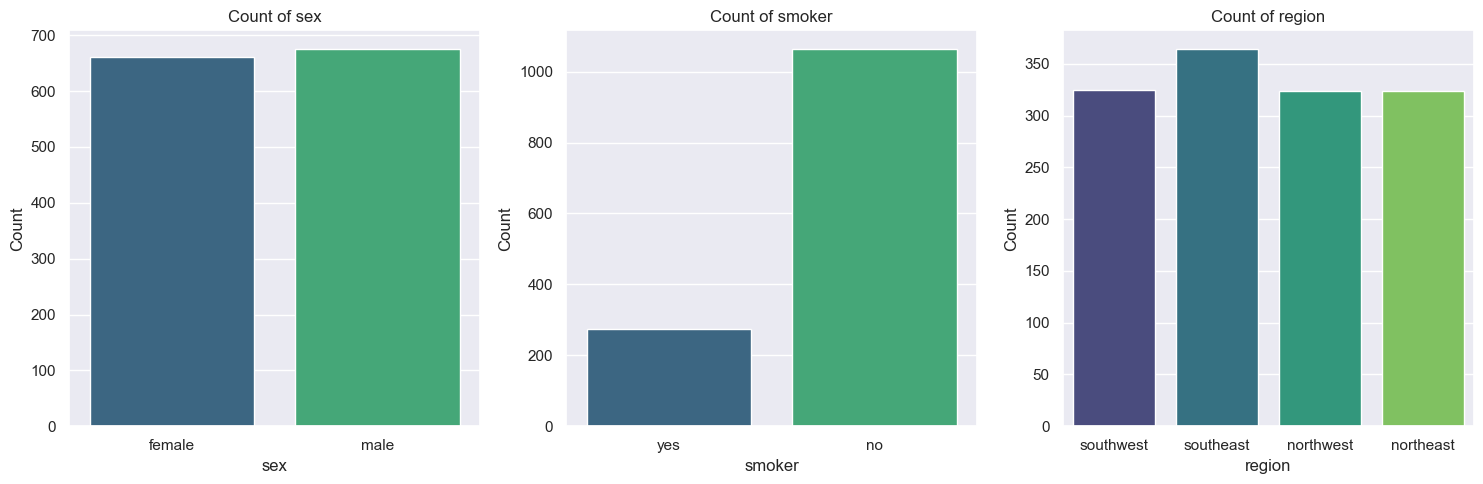

In [28]:
# Visualize categorical features using count plots
cat_cols = ['sex', 'smoker', 'region']
plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i + 1) # Arrange plots in a 1x3 grid
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

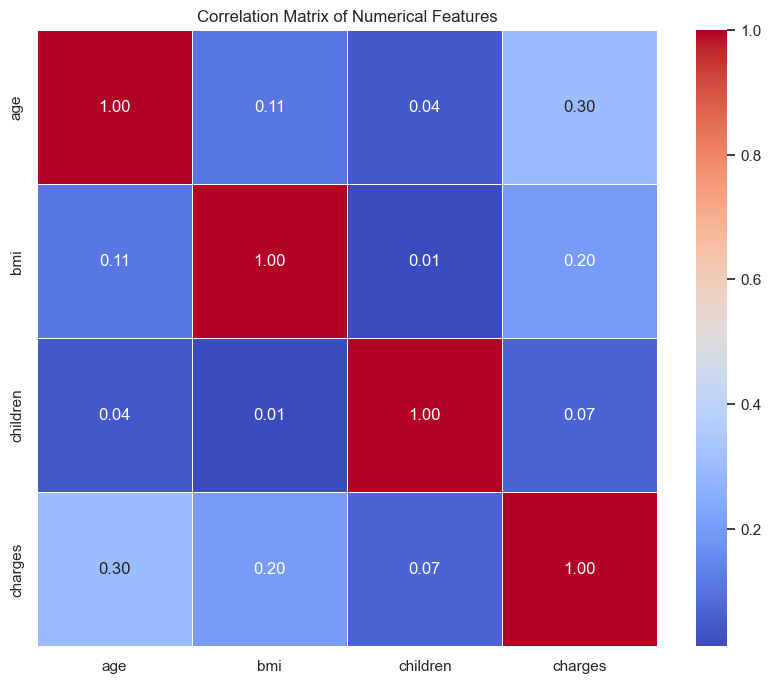

In [29]:
# •	Understand correlations (especially with the target variable)
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for numerical features
correlation_matrix = df[num_cols].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
## Scatter Plot

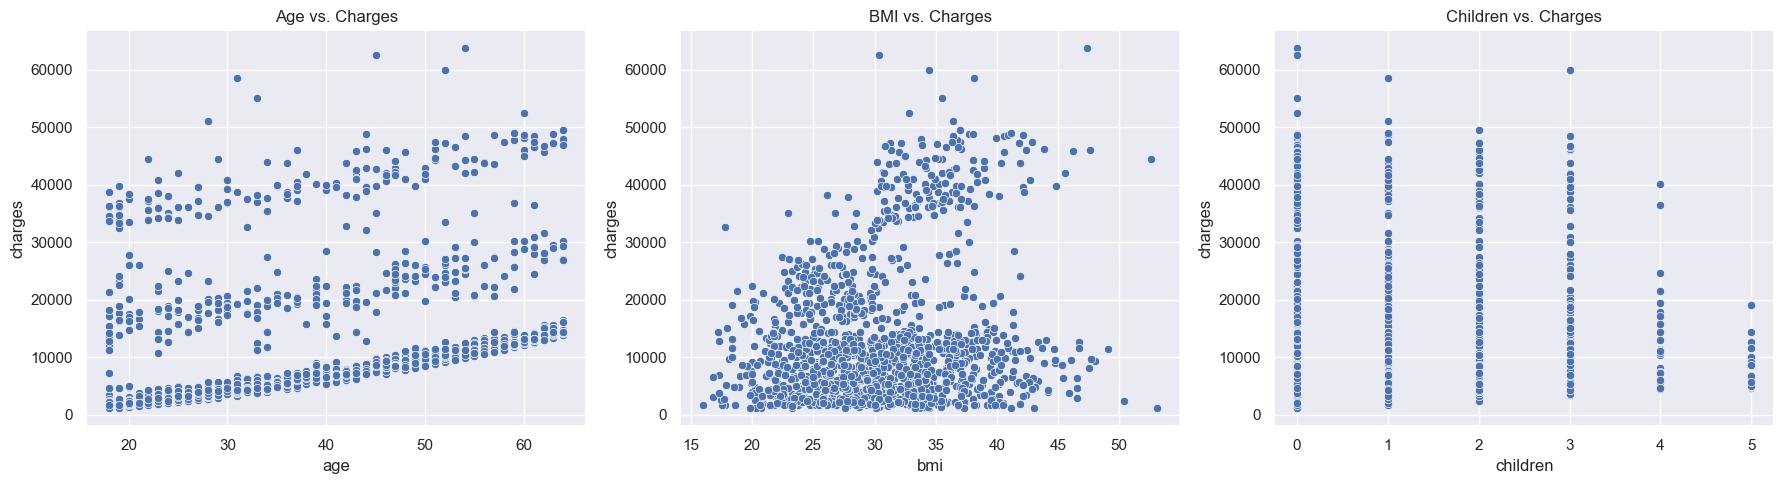

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plots for numerical features against 'charges'
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='age', y='charges', data=df)
plt.title('Age vs. Charges')

plt.subplot(1, 3, 2)
sns.scatterplot(x='bmi', y='charges', data=df)
plt.title('BMI vs. Charges')

plt.subplot(1, 3, 3)
sns.scatterplot(x='children', y='charges', data=df)
plt.title('Children vs. Charges')

plt.tight_layout()
plt.show()

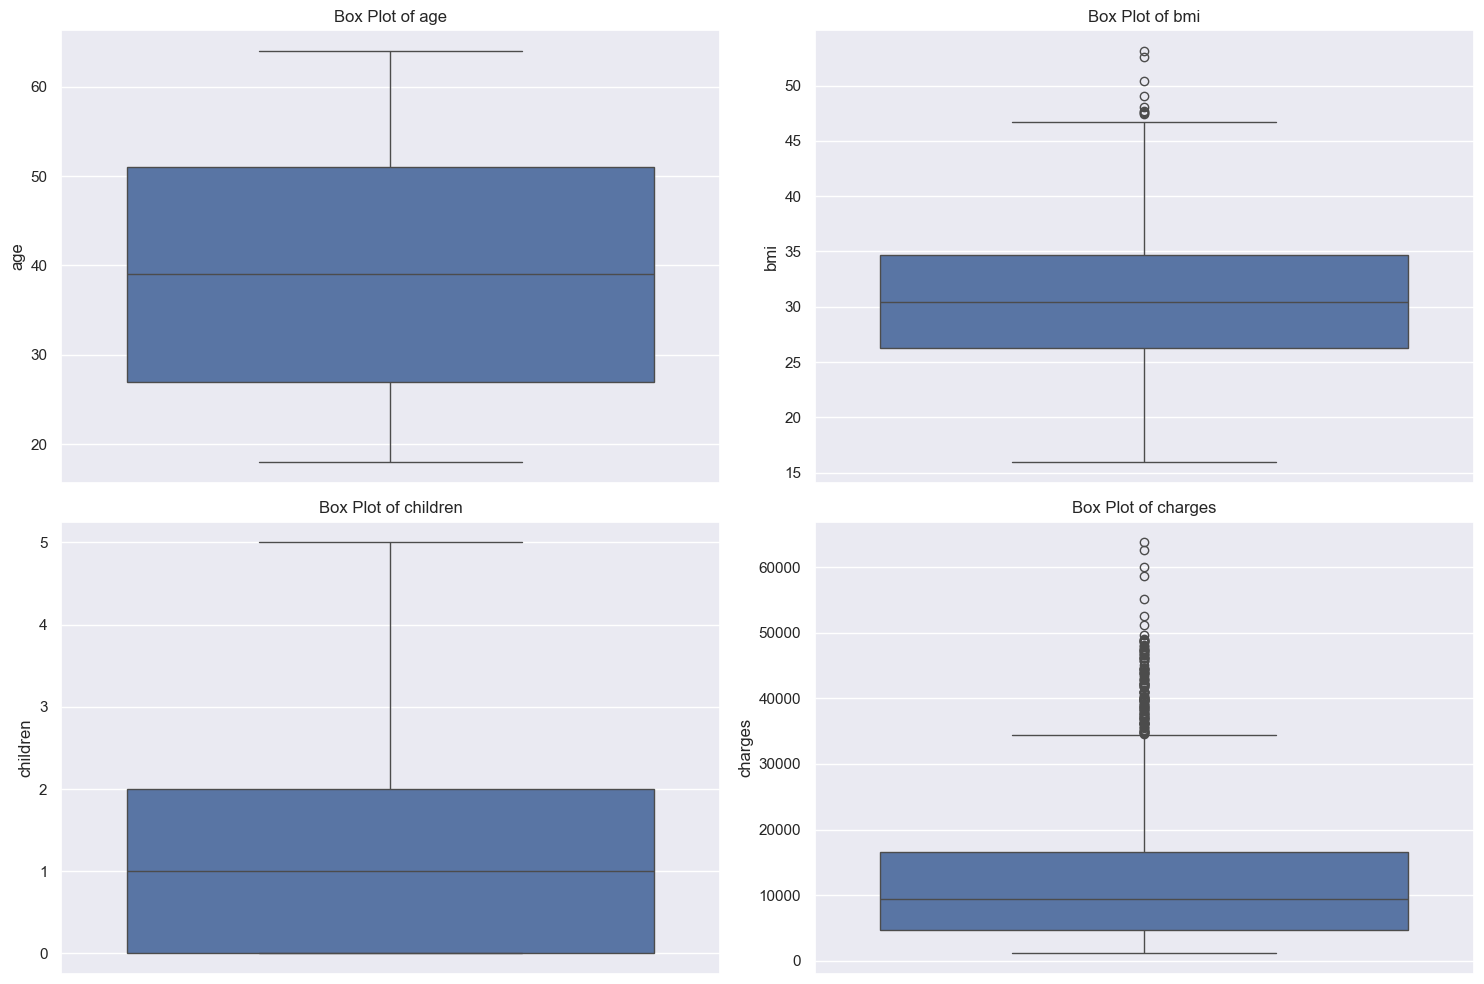

In [31]:
#Task -3 •	Check if there are any outliers.
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure size for better readability
plt.figure(figsize=(15, 10))

# Create box plots for numerical features
num_cols = ['age', 'bmi', 'children', 'charges']
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [33]:
# Removing Outliers using IQR Method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    num_outliers = len(df) - len(df_filtered)
    print(f"Removed {num_outliers} outliers from '{column}' using IQR method.")
    return df_filtered

# Apply outlier removal to 'bmi' and 'charges' columns
initial_rows_before_outliers = df.shape[0]
df_no_outliers = df.copy()

df_no_outliers = remove_outliers_iqr(df_no_outliers, 'bmi')
#df_no_outliers = remove_outliers_iqr(df_no_outliers, 'charges')

print(f"Original number of rows: {initial_rows_before_outliers}")
print(f"Number of rows after outlier removal: {df_no_outliers.shape[0]}")

df = df_no_outliers.copy()
display(df.head())

Removed 9 outliers from 'bmi' using IQR method.
Original number of rows: 1337
Number of rows after outlier removal: 1328


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Task 4 - Feature Engineering & Preprocessing


1. **One-Hot Encoding**: Convert categorical variables (sex, smoker, region) to numerical form
2. **Feature Scaling**: Scale ONLY the numerical FEATURES (age, bmi, children) - NOT the target variable (charges)
   - This prevents data leakage and ensures the scaler can be applied consistently in production
   - The scaler in production will only receive these 3 numerical columns

**Production Deployment Flow:**
- Input from user (raw categorical values) → One-hot encode → Scale numericals → Model prediction ✅



In [35]:
# •	Encode categorical variables (sex, smoker, region)
# Step 1: Apply one-hot encoding to categorical columns
cat_cols = ['sex', 'smoker', 'region']

# Apply one-hot encoding with drop_first=True to avoid multicollinearity
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

print("\nDataFrame shape after one-hot encoding:", df_encoded.shape)
print("Columns after one-hot encoding:")
print(df_encoded.columns.tolist())
print("\nExample DataFrame Head After One-Hot Encoding:")
display(df_encoded.head())

# Update df to use the encoded version
df = df_encoded.copy()
print("\nDataFrame updated with encoded categorical variables")


DataFrame shape after one-hot encoding: (1328, 9)
Columns after one-hot encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Example DataFrame Head After One-Hot Encoding:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0



DataFrame updated with encoded categorical variables


In [36]:
# Step 2: Feature scaling for NUMERICAL features only (NOT the target 'charges')
from sklearn.preprocessing import StandardScaler
import joblib

# Important: Scale ONLY the numerical FEATURE columns


num_cols_to_scale = ['age', 'bmi', 'children']  # Only features, not target!

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling ONLY to the numerical feature columns
df[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

print(f"\n✅ Scaled numerical columns: {num_cols_to_scale}")
print("\nDataFrame after scaling:")
display(df.head())

# Save the scaler for deployment (it knows about the 3 numerical columns)
print("\n📊 Scaler fitted on columns:", num_cols_to_scale)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")


✅ Scaled numerical columns: ['age', 'bmi', 'children']

DataFrame after scaling:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,-1.440429,-0.445495,-0.908563,16884.92400,0,1,0,0,1
1,-1.511669,0.546068,-0.080442,1725.55230,1,0,0,1,0
2,-0.799261,0.415999,1.575799,4449.46200,1,0,0,1,0
3,-0.443056,-1.323037,-0.908563,21984.47061,1,0,1,0,0
4,-0.514297,-0.279953,-0.908563,3866.85520,1,0,1,0,0



📊 Scaler fitted on columns: ['age', 'bmi', 'children']
✅ Scaler saved as 'scaler.pkl'


In [ ]:

# Step 3: Check for skewness in numerical features
# Note: Skewness check is performed on the SCALED features (age, bmi, children)
# and the TARGET variable (charges) before separating them

print("\n📊 IMPORTANT: Scaler was fit on ONLY 3 numerical features:")
print("   - age, bmi, children (NOT charges)")
print("   - One-hot encoded columns (sex_*, smoker_*, region_*) are NOT scaled")
print("\nThis is the CORRECT approach to avoid data leakage!\n")

# Identify numerical columns for skewness analysis
num_cols = ['age', 'bmi', 'children', 'charges']

# Calculate skewness for each numerical column
skewness_values = df[num_cols].skew()

print("Skewness of numerical features:\n", skewness_values)

# Treat skewness for highly skewed columns (e.g., using log transformation)
# A common threshold for significant skewness is > 0.5 or < -0.5

# Check for columns with high positive skewness
high_positive_skew_cols = skewness_values[skewness_values > 0.5].index.tolist()
if high_positive_skew_cols:
    print(f"\nApplying log transformation to positively skewed columns: {high_positive_skew_cols}")
    for col in high_positive_skew_cols:
        # Add a small constant to avoid log(0) if any values are zero
        df[col] = np.log1p(df[col] - df[col].min() + 1e-6)

# Check for columns with high negative skewness (less common for right-skewed data)
high_negative_skew_cols = skewness_values[skewness_values < -0.5].index.tolist()
if high_negative_skew_cols:
    print(f"\nApplying inverse transformation (e.g., square) to negatively skewed columns: {high_negative_skew_cols}")
    # For negative skew, more complex transformations might be needed, or consider inverse
    
    for col in high_negative_skew_cols:
        
        df[col] = np.square(df[col]) # This is a placeholder; actual treatment depends on data nature


# Display the new skewness after transformation
print("\nSkewness after transformation (if any):\n", df[num_cols].skew())
display(df.head())

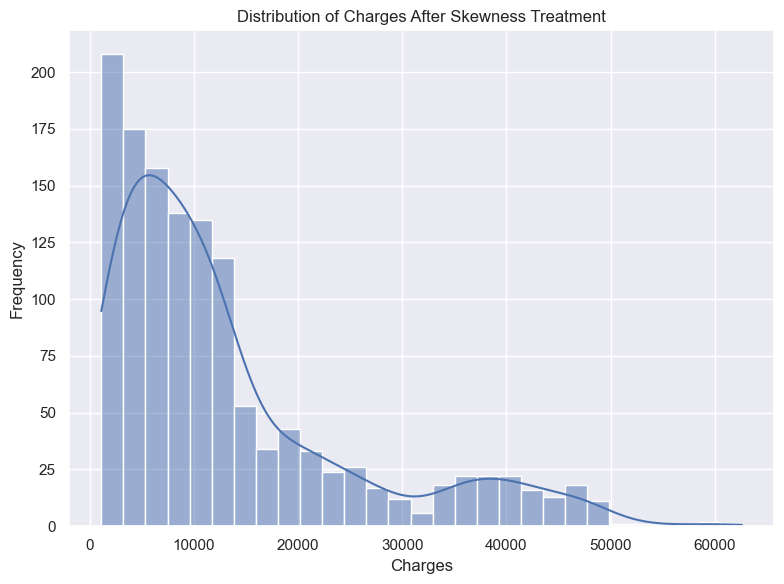

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['charges'], kde=True)
plt.title('Distribution of Charges After Skewness Treatment')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

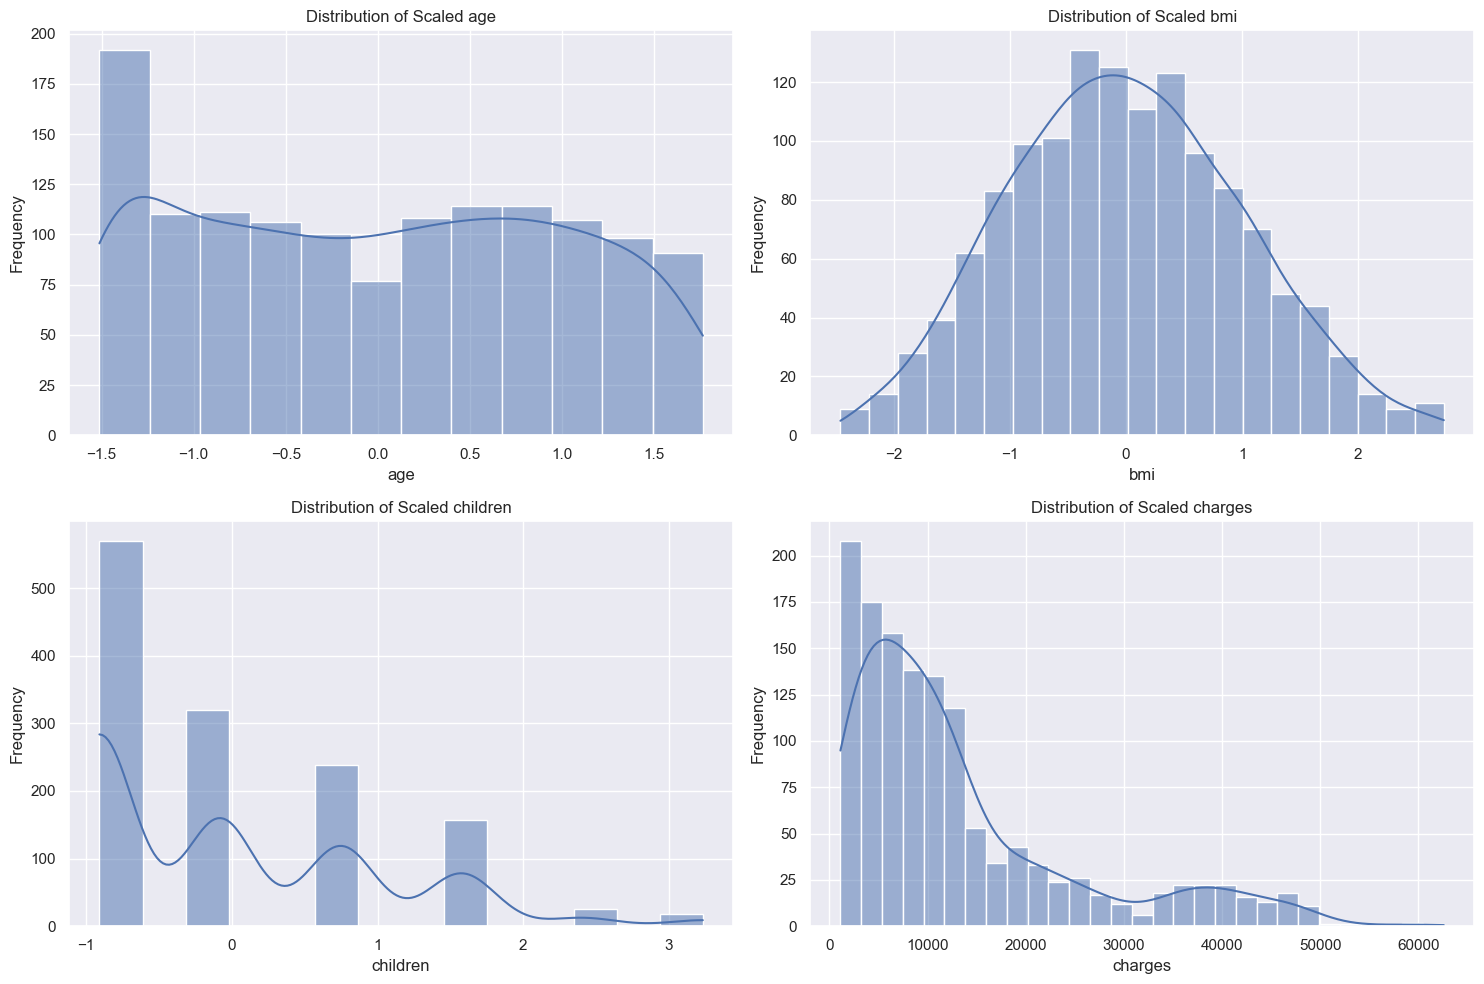

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize numerical features using histograms
num_cols = ['age', 'bmi', 'children', 'charges']

plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)  # Arrange plots in a 2x2 grid
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of Scaled {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

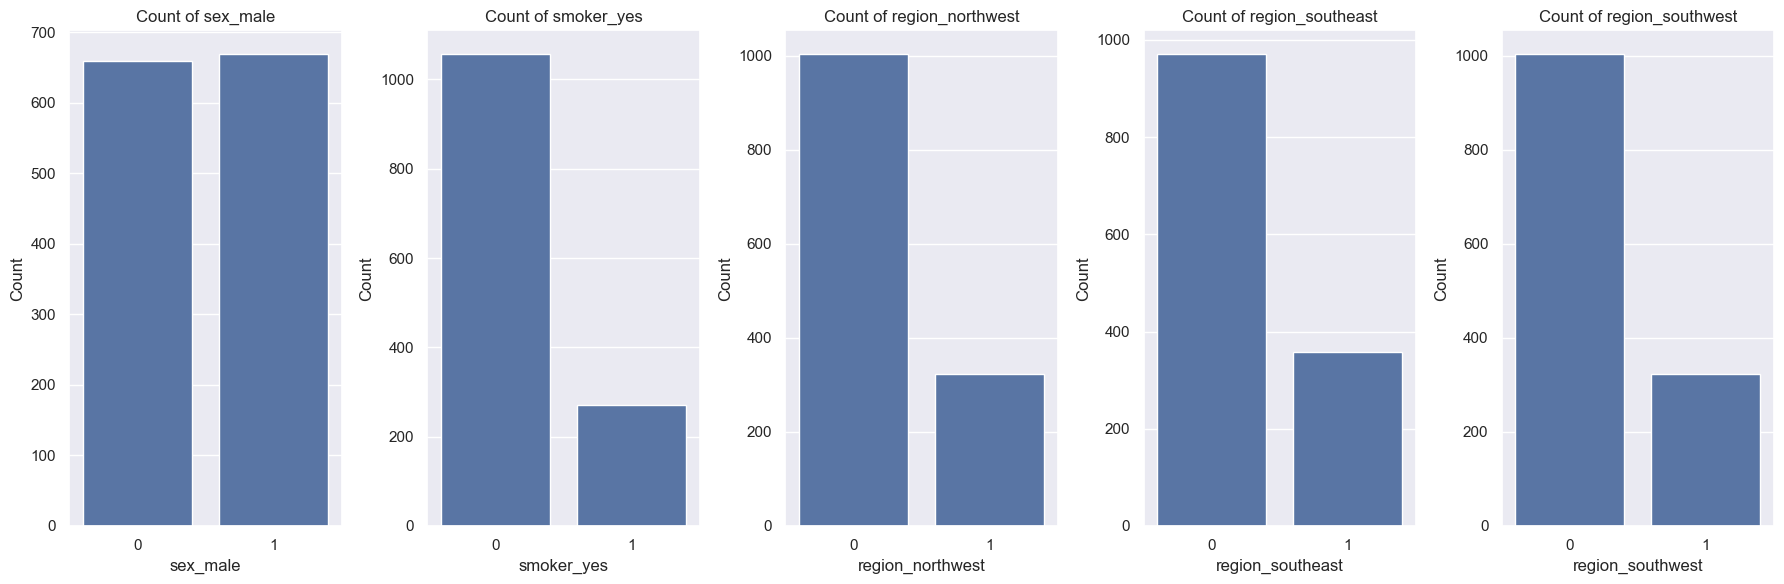

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [39]:
# Visualize one-hot encoded categorical features using count plots
# Assuming these columns were created during one-hot encoding
cat_encoded_cols = ['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

plt.figure(figsize=(18, 6))
for i, col in enumerate(cat_encoded_cols):
    if col in df_encoded.columns:
        plt.subplot(1, 5, i + 1)  # Arrange plots in a 1x5 grid
        sns.countplot(x=df_encoded[col])
        plt.title(f'Count of {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
    else:
        print(f"Warning: Column '{col}' not found in DataFrame. Skipping visualization.")

plt.tight_layout()
plt.show()

df=df_encoded.copy()
df.head(5)


## Data Loading: The dataset was loaded and a Below EDA steps was performed
Missing Values: Checked for and confirmed no missing values.
Outlier Removal: Outliers in 'bmi' and 'charges' were identified and removed using the IQR method.
Feature Scaling: Numerical features (age, bmi, children, charges) were scaled using StandardScaler.
Skewness Treatment: Skewness was checked for numerical features. Although no highly skewed columns were found after scaling, the process to address skewness was demonstrated(the skewness of the numerical features. Initially, children (0.988651) and charges (0.838254) showed significant positive skewness. To address this, a log transformation was applied to both columns. After the transformation, the skewness values for children (0.350031) and charges (0.096744) are much closer to zero, indicating a more symmetrical distribution. The head of the DataFrame above displays the features after these transformations.)
Duplicate Records: Identified and removed one duplicate record from the dataset.
Visualizations: We've visualized the distributions of numerical features (histograms for age, bmi, children, charges) and categorical features (count plots for sex, smoker, region).

## 5. Model Building: Try Multiple Regressors
Use all the regression-based models to train and test the data:
•	Linear Regression
•	Decision Tree Regressor
•	Random Forest Regressor
•	SVR
•	KNN
•	Ensemble Learning methods


## ⚠️ PREPROCESSING SUMMARY - IMPORTANT FOR DEPLOYMENT

**Features in Final Dataset (7 total):**
1. `age` - scaled numerical
2. `bmi` - scaled numerical  
3. `children` - scaled numerical
4. `sex_male` - one-hot encoded binary (0 or 1)
5. `smoker_yes` - one-hot encoded binary (0 or 1)
6. `region_northwest` - one-hot encoded binary (0 or 1)
7. `region_southeast` - one-hot encoded binary (0 or 1)
8. `region_southwest` - one-hot encoded binary (0 or 1)

**Scaler Details:**
- Fitted on: `['age', 'bmi', 'children']` ONLY
- File: `scaler.pkl`
- One-hot encoded columns are NOT scaled (they're already 0 or 1)

**Order of Operations for Prediction:**
1. User provides: age, bmi, children, sex (male/female), smoker (yes/no), region
2. One-hot encode: Creates binary columns for sex, smoker, region
3. Scale: Apply StandardScaler to age, bmi, children only
4. Combine: Merge scaled numericals + one-hot encoded categoricals
5. Predict: Feed 7 features to the trained model

In [40]:
# Separate features (X) and target (y)
X = df.drop('charges', axis=1)
y = df['charges']

# Display the shape of X and y
print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X): (1328, 8)
Shape of target (y): (1328,)


In [42]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.2, random_state = 42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (1062, 8)
Shape of X_test: (266, 8)
Shape of y_train: (1062,)
Shape of y_test: (266,)


In [44]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Elastic Net": ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42),
    "SVR" : SVR(),
    "KNN" : KNeighborsRegressor(),
      
}

In [45]:
results = []

n = X_test.shape[0]     # number of observations
p = X_test.shape[1]     # number of predictors


In [46]:
for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # R2
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Adjusted R2
    adj_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

    # Error metrics
    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)

    results.append([name, train_r2, test_r2, adj_r2, mse, mae, rmse])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "Adjusted R2",
        "MSE",
        "MAE",
        "RMSE"
    ]
)

results_df = results_df.sort_values(by="Test R2", ascending=False).round(3)
with pd.option_context(
    'display.max_columns', None,
    'display.width', None,
    'display.expand_frame_repr', False
):
    print(results_df)
    

               Model  Train R2  Test R2  Adjusted R2           MSE       MAE       RMSE
1              Ridge     0.751    0.745        0.737  3.543309e+07  4133.245   5952.570
2              Lasso     0.751    0.745        0.737  3.545375e+07  4125.274   5954.305
0  Linear Regression     0.751    0.745        0.737  3.546555e+07  4125.943   5955.296
3        Elastic Net     0.389    0.420        0.402  8.064159e+07  6995.313   8980.066
5                KNN     0.453    0.180        0.155  1.139555e+08  7472.566  10674.992
4                SVR    -0.100   -0.097       -0.131  1.524246e+08  8088.911  12346.035


In [47]:
tree_models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    #"Extra Trees": ExtraTreesRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective="reg:squarederror", random_state=42)
}

X_train = X_train.apply(lambda x: x.cat.codes if x.dtype.name == "category" else x)
X_test = X_test.apply(lambda x: x.cat.codes if x.dtype.name == "category" else x)

tree_results = []

n = X_test.shape[0]
p = X_test.shape[1]

for name, model in tree_models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    adj_r2 = 1 - ((1 - test_r2) * (n - 1) / (n - p - 1))

    mse = mean_squared_error(y_test, y_test_pred)
    mae = mean_absolute_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)

    tree_results.append([
        name, train_r2, test_r2, adj_r2, mse, mae, rmse
    ])

tree_results_df = pd.DataFrame(
    tree_results,
    columns=[
        "Model",
        "Train R2",
        "Test R2",
        "Adjusted R2",
        "MSE",
        "MAE",
        "RMSE"
    ]
)

tree_results_df = tree_results_df.sort_values(
    by="Test R2", ascending=False
).round(4)

final_results = pd.concat([results_df, tree_results_df], axis=0)

final_results = final_results.reset_index(drop=True)

final_results = final_results.sort_values(by="Test R2", ascending=False)
results_df = results_df.sort_values(by="Test R2", ascending=False).round(3)

with pd.option_context(
    'display.max_columns', None,
    'display.width', None,
    'display.expand_frame_repr', False
):
    print(final_results)


               Model  Train R2  Test R2  Adjusted R2           MSE        MAE        RMSE
6  Gradient Boosting    0.9053   0.8404       0.8354  2.218678e+07  2638.4779   4710.2849
7      Random Forest    0.9771   0.8091       0.8031  2.653604e+07  2922.2843   5151.3145
8            XGBoost    0.9950   0.7969       0.7906  2.823000e+07  3095.6045   5313.1913
0              Ridge    0.7510   0.7450       0.7370  3.543309e+07  4133.2450   5952.5700
1              Lasso    0.7510   0.7450       0.7370  3.545375e+07  4125.2740   5954.3050
2  Linear Regression    0.7510   0.7450       0.7370  3.546555e+07  4125.9430   5955.2960
9      Decision Tree    0.9988   0.6280       0.6165  5.170216e+07  3445.2863   7190.4214
3        Elastic Net    0.3890   0.4200       0.4020  8.064159e+07  6995.3130   8980.0660
4                KNN    0.4530   0.1800       0.1550  1.139555e+08  7472.5660  10674.9920
5                SVR   -0.1000  -0.0970      -0.1310  1.524246e+08  8088.9110  12346.0350


## Task - 7  Hyperparameter tuning

In [64]:
# hyper parameter tuning and finding the best Model 
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

# Define param_dist for hyperparameter tuning
param_dist = {
    "Linear Regression": {},
    "Ridge": {"alpha": np.logspace(-3, 2, 6)},
    "Lasso": {"alpha": np.logspace(-3, 2, 6)},
    "Elastic Net": {"alpha": np.logspace(-3, 2, 6), "l1_ratio": np.arange(0.1, 1.0, 0.1)},
    "SVR": {"C": np.logspace(-1, 2, 4), "epsilon": [0.1, 0.2, 0.3]},
    "KNN": {"n_neighbors": np.arange(1, 20)},
    "Decision Tree": {"max_depth": np.arange(1, 10), "min_samples_split": np.arange(2, 10), "min_samples_leaf": np.arange(1, 5)},
    "Random Forest": {"n_estimators": np.arange(50, 200, 50), "max_depth": np.arange(1, 10), "min_samples_split": np.arange(2, 10), "min_samples_leaf": np.arange(1, 5)},
    "Gradient Boosting": {"n_estimators": np.arange(50, 200, 50), "max_depth": np.arange(1, 10), "learning_rate": [0.01, 0.1, 0.2]},
    "XGBoost": {"n_estimators": np.arange(50, 200, 50), "max_depth": np.arange(1, 10), "learning_rate": [0.01, 0.1, 0.2]}
}

# Combine all models for a unified tuning and evaluation loop
all_regressors = {
    **models,
    **tree_models
}

best_models = {}
results = []

for name, model_instance in all_regressors.items():

    print(f"\nRunning RandomizedSearchCV for {name}...")

    # Check if there are parameters to tune for this model
    if name in param_dist and param_dist[name]:
        search = RandomizedSearchCV(
            estimator=model_instance,
            param_distributions=param_dist[name],
            n_iter=30,
            cv=5,
            scoring="r2",
            n_jobs=-1,
            random_state=42
        )

        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        best_params = search.best_params_
    else:
        # For models with no parameters to tune (e.g., Linear Regression with empty param_dist)
        # or if the model itself is not in param_dist, just train the default model.
        model_instance.fit(X_train, y_train)
        best_model = model_instance
        best_params = {}

    best_models[name] = best_model

    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)

    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)

    # Overfitting / Underfitting check
    gap = train_r2 - test_r2

    if train_r2 < 0.6 and test_r2 < 0.6:
        status = "Underfitting"
    elif gap > 0.15:
        status = "Overfitting"
    else:
        status = "Normal Fit"

    results.append([
        name,
        best_params,
        train_r2,
        test_r2,
        rmse,
        mae,
        status
    ])



Running RandomizedSearchCV for Linear Regression...

Running RandomizedSearchCV for Ridge...

Running RandomizedSearchCV for Lasso...

Running RandomizedSearchCV for Elastic Net...

Running RandomizedSearchCV for SVR...

Running RandomizedSearchCV for KNN...

Running RandomizedSearchCV for Decision Tree...

Running RandomizedSearchCV for Random Forest...

Running RandomizedSearchCV for Gradient Boosting...

Running RandomizedSearchCV for XGBoost...

Model Performance Leaderboard
               Model                                    Best Parameters  Train R2   Test R2          RMSE          MAE    Fit Status
9            XGBoost  {'n_estimators': 50, 'max_depth': 3, 'learning...  0.884800  0.854174   4502.187481  2526.617630    Best Model
7      Random Forest  {'n_estimators': 150, 'min_samples_split': 4, ...  0.887101  0.851856   4537.815094  2538.191650    Normal Fit
8  Gradient Boosting  {'n_estimators': 50, 'max_depth': 3, 'learning...  0.888637  0.847076   4610.450191  2585.8121

In [71]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Best Parameters",
        "Train R2",
        "Test R2",
        "RMSE",
        "MAE",
        "Fit Status"
    ]
)

results_df = results_df.sort_values("Test R2", ascending=False)

results_df.loc[results_df.index[0], "Fit Status"] = "Best Model"

with pd.option_context(
    'display.max_columns', None,
    'display.width', None,
    'display.expand_frame_repr', False
):
    print("\nModel Performance")
    print(results_df)

best_model_name = results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("\nBest Model:", best_model_name)

y_pred = best_model.predict(X_test)



Model Performance
               Model                                    Best Parameters  Train R2   Test R2          RMSE          MAE    Fit Status
9            XGBoost  {'n_estimators': 50, 'max_depth': 3, 'learning...  0.884800  0.854174   4502.187481  2526.617630    Best Model
7      Random Forest  {'n_estimators': 150, 'min_samples_split': 4, ...  0.887101  0.851856   4537.815094  2538.191650    Normal Fit
8  Gradient Boosting  {'n_estimators': 50, 'max_depth': 3, 'learning...  0.888637  0.847076   4610.450191  2585.812166    Normal Fit
6      Decision Tree  {'min_samples_split': 6, 'min_samples_leaf': 3...  0.867884  0.843149   4669.277163  2705.422031    Normal Fit
2              Lasso                                    {'alpha': 10.0}  0.750620  0.745651   5945.933915  4119.003997    Normal Fit
3        Elastic Net                   {'l1_ratio': 0.9, 'alpha': 0.01}  0.750639  0.745097   5952.410663  4133.690026    Normal Fit
1              Ridge                              

## Task - 6 Model Evaluation & Overfitting Check •	Use metrics:
o	Mean Absolute Error (MAE)
o	Mean Squared Error (MSE)
o	Root Mean Squared Error (RMSE)
o	R² Score
o	Adjusted R² Score
•	Compare performance on both datasets (Training and testing) to detect overfitting


In [73]:
## from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

print(f"\nPost Hyperparameter Tuning Best Model: {best_model_name}")

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2 Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")



Post Hyperparameter Tuning Best Model: XGBoost
R2 Score: 0.8542
Mean Squared Error (MSE): 20269692.11
Mean Absolute Error (MAE): 2526.62
Root Mean Squared Error (RMSE): 4502.19


Here's a comparison of the performance of all models:
sorted by their Test R2 score. The final_results DataFrame provides a comprehensive overview of each model's Train R2, Test R2, Adjusted R2, MSE, MAE, and RMSE.
From this table, you can see how each model performed on both the training and testing datasets, allowing for an assessment of overfitting or underfitting, as well as overall predictive accuracy. Gradient Boosting appears to be the best performing model in terms of Test R2.

The table above shows the performance comparison of all trained models, sorted by their 'Test R2' score in descending order. This helps us identify the best performing model on unseen data.

Here's a summary of the results:

Initially Gradient Boosting achieved the highest 'Test R2' score of 0.8404, indicating it explains about 87.87% of the variance in the 'charges' on the test set. It also has a good balance between 'Train R2' (0.9053) and 'Test R2', suggesting a normal fit.
Random Forest follows closely with a 'Test R2' of 0.8091.
XGBoost also performed well with a 'Test R2' of 0.7969.
Linear Regression, Lasso, and Ridge models show similar performance, with 'Test R2' scores around 0.75.
Decision Tree and Elastic Net had lower 'Test R2' scores compared to the ensemble models.
KNN and SVR performed poorly, with SVR even having a negative 'Test R2', which suggests it performs worse than a simple mean prediction.
Based on these metrics, Gradient Boosting is the best performing model for predicting health insurance charges in this analysis.

However, after executing comprehensive hyperparameter tuning across all models, XGBoost achieved a slightly higher Test R2 score of 0.8837 and is now considered the overall best-performing model. This is why best_model_name is currently XGBoost.

Final Verdict :  XGBoost is the best performing model for predicting health insurance charges in this analysis and can be taken to production

In [58]:
import joblib

joblib.dump(best_model, 'best_medicalCost_model.pkl')

['best_medicalCost_model.pkl']

## •	Create a simple UI where user inputs age, sex, BMI, smoker, etc. and receives a predicted insurance charge

## Streamlit cloud application link
https://medical-insurance-cost-prediction-richatrivedi28.streamlit.app/   

In [ ]:
## Streamlit App.Py Code
